In [17]:
pip install torch torchvision --index-url https://download.pytorch.org/whl/cu124


Defaulting to user installation because normal site-packages is not writeable
Looking in indexes: https://download.pytorch.org/whl/cu124
Note: you may need to restart the kernel to use updated packages.


In [18]:
# =============================================================================
# Evaluation Benchmark & Ablation Protocol
# Models: SVM, RF, GBM, CNN, LSTM, CNN-LSTM, TCN
# Protocols: session-blocked (mixed k-fold) and leave-one-participant-out
# Metrics: Macro-F1, Balanced Accuracy, Accuracy
# =============================================================================

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

from Python.integrations import load_gym_dataset
from Python.windows import create_adaptive_windows
from Python.feature_engineering import engineer_robust_features
from Python.posthoc import ML4QSFlexiblePipeline
from Python.evaluation import run_full_evaluation, print_benchmark_summary, print_ablation_summary

plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False})

In [19]:
# ── 1. LOAD & CLEAN DATA ─────────────────────────────────────────────────────
print("Loading dataset...")
raw_data = load_gym_dataset(Path("./Datasets/cropped"))

print(f"Total samples  : {len(raw_data):,}")
print(f"Participants   : {sorted(raw_data['participant'].unique())}")
print(f"Activities     : {sorted(raw_data['activity_label'].unique())}")
print(f"Sessions/person: {raw_data.groupby('participant')['session'].nunique().to_dict()}")

SENSOR_COLS = [
    "acc_x", "acc_y", "acc_z",
    "gyro_x", "gyro_y", "gyro_z",
    "grav_x", "grav_y", "grav_z",
    "magnet_x", "magnet_y", "magnet_z",
    "acc_vert", "acc_horiz", "gyro_vert", "gyro_horiz",
]
total_missing = int(raw_data[SENSOR_COLS].isnull().sum().sum())
print(f"\nMissing sensor readings: {total_missing}")
if total_missing > 0:
    raw_data[SENSOR_COLS] = (
        raw_data.groupby(["participant", "session"])[SENSOR_COLS]
        .transform(lambda g: g.interpolate(method="linear").ffill().bfill())
    )
    print(f"Remaining after interpolation: {int(raw_data[SENSOR_COLS].isnull().sum().sum())}")
else:
    print("No missing values.")

Loading dataset...
Gym Movements Dataset loaded:
  Total samples : 221,681
  Participants  : ['imaan', 'richard']
  Activities    : ['elliptical', 'lat_pull', 'lunge', 'row', 'threadmill']
  Sessions      : 88
  Columns       : ['time', 'acc_x', 'acc_y', 'acc_z', 'gyro_x', 'gyro_y', 'gyro_z', 'grav_x', 'grav_y', 'grav_z', 'orient_qz', 'orient_qy', 'orient_qx', 'orient_qw', 'orient_roll', 'orient_pitch', 'orient_yaw', 'magnet_x', 'magnet_y', 'magnet_z', 'acc_vert', 'acc_horiz', 'gyro_vert', 'gyro_horiz', 'activity_label', 'participant', 'session', 'data_source']
Total samples  : 221,681
Participants   : ['imaan', 'richard']
Activities     : ['elliptical', 'lat_pull', 'lunge', 'row', 'threadmill']
Sessions/person: {'imaan': 48, 'richard': 40}

Missing sensor readings: 68
Remaining after interpolation: 0


In [20]:
# ── 2. WINDOWING ──────────────────────────────────────────────────────────────
windowed_data = create_adaptive_windows(
    raw_data,
    min_window_size=64,
    preferred_window_size=128,   # 2.56 s @ 50 Hz
    overlap_ratio=0.5,
)


Window creation summary:
  Full-size windows: 3334
  Adaptive windows: 0
  Rejected segments: 0
  Total windows: 3334


In [21]:
# ── 3. CLASSICAL FEATURE MATRIX ───────────────────────────────────────────────
print("Extracting hand-crafted features...")
features, labels, feature_names, metadata = engineer_robust_features(
    windowed_data, sampling_rate=50
)
print(f"Feature matrix : {features.shape}")
print(f"Labels         : {dict(zip(*np.unique(labels, return_counts=True)))}")

Extracting hand-crafted features...
  Processing window 0/3334...
  Processing window 100/3334...
  Processing window 200/3334...
  Processing window 300/3334...
  Processing window 400/3334...
  Processing window 500/3334...
  Processing window 600/3334...
  Processing window 700/3334...
  Processing window 800/3334...
  Processing window 900/3334...
  Processing window 1000/3334...
  Processing window 1100/3334...
  Processing window 1200/3334...
  Processing window 1300/3334...
  Processing window 1400/3334...
  Processing window 1500/3334...
  Processing window 1600/3334...
  Processing window 1700/3334...
  Processing window 1800/3334...
  Processing window 1900/3334...
  Processing window 2000/3334...
  Processing window 2100/3334...
  Processing window 2200/3334...
  Processing window 2300/3334...
  Processing window 2400/3334...
  Processing window 2500/3334...
  Processing window 2600/3334...
  Processing window 2700/3334...
  Processing window 2800/3334...
  Processing window

In [22]:
# ── 3b. PARTICIPANT / ACTIVITY COVERAGE AUDIT ─────────────────────────────────
# Verify that both participants performed every activity, and check window counts
# and proportions. An activity absent from one participant cannot be learned in
# that LOPO direction.
import pandas as pd

audit = pd.DataFrame(metadata).copy()
audit["activity"]      = labels
audit["session_group"] = (
    audit["participant"].astype(str) + "__" + audit["session"].astype(str)
)

print("=== Window counts by participant and activity ===")
display(pd.crosstab(audit["participant"], audit["activity"], margins=True))

print("\n=== Activity proportions by participant ===")
display(
    pd.crosstab(audit["participant"], audit["activity"], normalize="index").round(3)
)

print("\n=== Window counts by participant × session × activity (first 20 rows) ===")
display(
    pd.crosstab(
        [audit["participant"], audit["session_group"]],
        audit["activity"],
        margins=True,
    ).head(20)
)

=== Window counts by participant and activity ===


activity,elliptical,lat_pull,lunge,row,threadmill,All
participant,,,,,,
imaan,206,265,0,300,271,1042
richard,778,379,218,222,695,2292
All,984,644,218,522,966,3334



=== Activity proportions by participant ===


activity,elliptical,lat_pull,lunge,row,threadmill
participant,,,,,
imaan,0.198,0.254,0.000,0.288,0.260
richard,0.339,0.165,0.095,0.097,0.303



=== Window counts by participant × session × activity (first 20 rows) ===


activity                   elliptical  lat_pull  lunge  row  threadmill  All
participant session_group                                                   
imaan       imaan__0               10         0      0    0           0   10
            imaan__1                8         0      0    0           0    8
            imaan__10              25         0      0    0           0   25
            imaan__11              30         0      0    0           0   30
            imaan__19               0        25      0    0           0   25
            imaan__2                8         0      0    0           0    8
            imaan__20               0        21      0    0           0   21
            imaan__21               0        21      0    0           0   21
            imaan__22               0        19      0    0           0   19
            imaan__23               0        26      0    0           0   26
            imaan__24               0        24      0    0           0   24
            imaan__25               0        28      0    0           0   28
            imaan__26               0        21      0    0           0   21
            imaan__27               0        17      0    0           0   17
            imaan__28               0        20      0    0           0   20
            imaan__29               0        19      0    0           0   19
            imaan__3                8         0      0    0           0    8
            imaan__30               0        24      0    0           0   24
            imaan__4               20         0      0    0           0   20
            imaan__5               24         0      0    0           0   24

In [23]:
# ── 5. SESSION_BLOCKED RESULTS (recovered from evaluation_block.txt) ─────────
import os, json
import numpy as np

SAVE_DIR  = "./Results"
PLOTS_DIR = "./Plots"
PARTIAL   = os.path.join(SAVE_DIR, "evaluation_partial.json")

RECOVERED_RUN_METADATA = {
    "source": "console output from completed session-blocked run",
    "serialization_status": "run completed; process crashed before output file write",
    "values_entered_manually": True,
    "temporary": True,
    "evaluation_protocol": "session-blocked",
    "notes": "Replace with persisted output when rerun or recovered.",
}

# ── Hardcoded observed means (classical benchmark) ────────────────────────────
_SB_F1_BASE  = {"rf": 0.9753, "svm": 0.9728, "gbm": 0.9733}
_SB_BAC_BASE = {"rf": 0.9751, "svm": 0.9729, "gbm": 0.9716}
_SB_ACC_BASE = {"rf": 0.9751, "svm": 0.9708, "gbm": 0.9736}

# ── Ablation deltas (macro_f1) — observed from console output ─────────────────
_ABL_DELTA_F1 = {
    "drop_axis_x":             {"rf": -0.0018, "svm": -0.0010, "gbm": -0.0038},
    "isolate_axis_x":          {"rf": -0.0112, "svm": +0.0019, "gbm": -0.0098},
    "drop_axis_y":             {"rf": +0.0004, "svm": +0.0006, "gbm": -0.0009},
    "isolate_axis_y":          {"rf": -0.0163, "svm": -0.0128, "gbm": -0.0221},
    "drop_axis_z":             {"rf": -0.0015, "svm": +0.0018, "gbm": +0.0024},
    "isolate_axis_z":          {"rf": -0.0107, "svm": -0.0061, "gbm": -0.0159},
    "drop_correlations":       {"rf": +0.0005, "svm": -0.0012, "gbm": -0.0012},
    "isolate_correlations":    {"rf": -0.0065, "svm": -0.0032, "gbm": -0.0098},
    "drop_freq_domain":        {"rf": +0.0007, "svm": +0.0015, "gbm": -0.0004},
    "isolate_freq_domain":     {"rf": -0.0098, "svm": -0.0055, "gbm": -0.0115},
    "drop_gravity_aligned":    {"rf": +0.0005, "svm": +0.0003, "gbm": -0.0003},
    "isolate_gravity_aligned": {"rf": -0.0211, "svm": -0.0144, "gbm": -0.0212},
    "drop_magnitude":          {"rf": -0.0001, "svm": +0.0008, "gbm": +0.0007},
    "isolate_magnitude":       {"rf": -0.0187, "svm": -0.0203, "gbm": -0.0272},
    "drop_sensor_acc":         {"rf": +0.0005, "svm": +0.0002, "gbm": -0.0000},
    "isolate_sensor_acc":      {"rf": -0.0141, "svm": -0.0171, "gbm": -0.0213},
    "drop_sensor_grav":        {"rf": -0.0001, "svm": +0.0005, "gbm": -0.0023},
    "isolate_sensor_grav":     {"rf": -0.0024, "svm": +0.0022, "gbm": -0.0004},
    "drop_sensor_gyro":        {"rf": +0.0004, "svm": +0.0007, "gbm": +0.0007},
    "isolate_sensor_gyro":     {"rf": -0.0289, "svm": -0.0197, "gbm": -0.0183},
    "drop_sensor_magnet":      {"rf": -0.0025, "svm": -0.0006, "gbm": -0.0003},
    "isolate_sensor_magnet":   {"rf": -0.0060, "svm": +0.0002, "gbm": -0.0152},
    "drop_time_domain":        {"rf": -0.0034, "svm": -0.0016, "gbm": -0.0008},
    "isolate_time_domain":     {"rf": -0.0011, "svm": +0.0002, "gbm": +0.0003},
}

# ── Ablation deltas (balanced_acc) — observed from console output ─────────────
_ABL_DELTA_BAC = {
    "drop_axis_x":             {"rf": -0.0023, "svm": -0.0012, "gbm": -0.0019},
    "isolate_axis_x":          {"rf": -0.0117, "svm": +0.0017, "gbm": -0.0100},
    "drop_axis_y":             {"rf": +0.0000, "svm": -0.0000, "gbm": +0.0007},
    "isolate_axis_y":          {"rf": -0.0155, "svm": -0.0066, "gbm": -0.0180},
    "drop_axis_z":             {"rf": -0.0019, "svm": +0.0015, "gbm": +0.0018},
    "isolate_axis_z":          {"rf": -0.0114, "svm": -0.0059, "gbm": -0.0163},
    "drop_correlations":       {"rf": +0.0002, "svm": -0.0004, "gbm": -0.0006},
    "isolate_correlations":    {"rf": -0.0073, "svm": -0.0032, "gbm": -0.0103},
    "drop_freq_domain":        {"rf": +0.0003, "svm": +0.0003, "gbm": -0.0001},
    "isolate_freq_domain":     {"rf": -0.0086, "svm": -0.0032, "gbm": -0.0080},
    "drop_gravity_aligned":    {"rf": +0.0004, "svm": +0.0001, "gbm": -0.0003},
    "isolate_gravity_aligned": {"rf": -0.0167, "svm": -0.0102, "gbm": -0.0166},
    "drop_magnitude":          {"rf": -0.0003, "svm": +0.0006, "gbm": +0.0003},
    "isolate_magnitude":       {"rf": -0.0206, "svm": -0.0240, "gbm": -0.0266},
    "drop_sensor_acc":         {"rf": +0.0004, "svm": -0.0005, "gbm": +0.0000},
    "isolate_sensor_acc":      {"rf": -0.0159, "svm": -0.0126, "gbm": -0.0194},
    "drop_sensor_grav":        {"rf": -0.0009, "svm": -0.0007, "gbm": -0.0015},
    "isolate_sensor_grav":     {"rf": -0.0028, "svm": +0.0044, "gbm": -0.0000},
    "drop_sensor_gyro":        {"rf": +0.0001, "svm": +0.0007, "gbm": +0.0009},
    "isolate_sensor_gyro":     {"rf": -0.0268, "svm": -0.0188, "gbm": -0.0160},
    "drop_sensor_magnet":      {"rf": -0.0021, "svm": -0.0010, "gbm": -0.0004},
    "isolate_sensor_magnet":   {"rf": -0.0073, "svm": -0.0021, "gbm": -0.0145},
    "drop_time_domain":        {"rf": -0.0022, "svm": -0.0008, "gbm": -0.0007},
    "isolate_time_domain":     {"rf": -0.0013, "svm": -0.0013, "gbm": +0.0015},
}

def _make_session_blocked():
    classical = {
        m: {
            "mean_macro_f1":     _SB_F1_BASE[m],
            "mean_balanced_acc": _SB_BAC_BASE[m],
            "mean_accuracy":     _SB_ACC_BASE[m],
        }
        for m in ("rf", "svm", "gbm")
    }

    dl = {
        "cnn":      {"mean_macro_f1": 0.9799, "mean_balanced_acc": 0.9805, "mean_accuracy": 0.9787},
        "lstm":     {"mean_macro_f1": 0.9633, "mean_balanced_acc": 0.9690, "mean_accuracy": 0.9680},
        "cnn_lstm": {"mean_macro_f1": 0.9732, "mean_balanced_acc": 0.9781, "mean_accuracy": 0.9765},
        "tcn":      {"mean_macro_f1": 0.9826, "mean_balanced_acc": 0.9830, "mean_accuracy": 0.9823},
    }

    # "full" baseline — all three metrics directly observed
    abl = {
        "full": {
            m: {
                "mean_macro_f1":     _SB_F1_BASE[m],
                "mean_balanced_acc": _SB_BAC_BASE[m],
                "mean_accuracy":     _SB_ACC_BASE[m],
            }
            for m in ("rf", "svm", "gbm")
        }
    }
    # Ablation conditions: macro_f1 and balanced_acc observed; accuracy NOT observed
    # — do not infer accuracy from balanced-acc deltas; leave as nan.
    for cond, df1 in _ABL_DELTA_F1.items():
        abl[cond] = {
            m: {
                "mean_macro_f1":     round(_SB_F1_BASE[m]  + df1[m], 4),
                "mean_balanced_acc": round(_SB_BAC_BASE[m] + _ABL_DELTA_BAC[cond][m], 4),
                "mean_accuracy":     float("nan"),   # not observed in console output
            }
            for m in ("rf", "svm", "gbm")
        }

    return {
        "classical": classical,
        "dl": dl,
        "ablation_classical": abl,
        "_recovery_metadata": RECOVERED_RUN_METADATA,
    }

results = {"session_blocked": _make_session_blocked()}
print("Recovered session_blocked from evaluation_block.txt")
print(f"  Classical : {list(results['session_blocked']['classical'].keys())}")
print(f"  DL        : {list(results['session_blocked']['dl'].keys())}")
print(f"  Ablation  : {len(results['session_blocked']['ablation_classical'])} conditions")
print(f"  Provenance: {RECOVERED_RUN_METADATA['source']}")

Recovered session_blocked from evaluation_block.txt
  Classical : ['rf', 'svm', 'gbm']
  DL        : ['cnn', 'lstm', 'cnn_lstm', 'tcn']
  Ablation  : 25 conditions
  Provenance: console output from completed session-blocked run


### Recovered session-blocked results

The following cell contains results **manually transcribed from console output** of a
completed evaluation run. The process crashed before the final results file was written.
These values are retained as recovered experimental results — **not newly computed by
this notebook execution**. Before final submission they should be replaced by a persisted
result artifact from a successful end-to-end run.

In [24]:
# ── 5b. RUN LOPO ──────────────────────────────────────────────────────────────
import numpy as np
from Python.evaluation import run_full_evaluation

# Build raw sequences array (N, T, 10) expected by the DL models
_DL_CHANNELS = [
    "acc_x", "acc_y", "acc_z",
    "gyro_x", "gyro_y", "gyro_z",
    "acc_vert", "acc_horiz", "gyro_vert", "gyro_horiz",
]
sequences = np.stack(
    [np.stack([w[ch] for ch in _DL_CHANNELS], axis=-1) for w in windowed_data]
)  # (N, T, 10)
print(f"Sequences shape: {sequences.shape}")


def _lopo_complete(result):
    """Return True only if the lopo result contains all expected sections."""
    if not isinstance(result, dict):
        return False
    classical = set(result.get("classical", {}).keys())
    dl        = set(result.get("dl", {}).keys())
    ablation  = result.get("ablation_classical", {})
    return (
        {"rf", "svm", "gbm"}.issubset(classical)
        and {"cnn", "lstm", "cnn_lstm", "tcn"}.issubset(dl)
        and "full" in ablation
    )


# Resume from partial save if lopo already completed and is valid
_lopo_done = False
if os.path.exists(PARTIAL):
    with open(PARTIAL) as f:
        _partial = json.load(f)
    if "lopo" in _partial:
        if _lopo_complete(_partial["lopo"]):
            print("lopo already completed — loading from partial save.")
            results["lopo"] = _partial["lopo"]
            _lopo_done = True
        else:
            print("Partial lopo file found but appears incomplete — will resume run.")

if not _lopo_done:
    print("Running lopo evaluation...")
    lopo_res = run_full_evaluation(
        features               = features,
        labels                 = labels,
        feature_names          = feature_names,
        metadata               = metadata,
        sequences              = sequences,
        run_dl_models          = True,
        run_ablation_classical = True,
        run_ablation_dl        = False,
        classical_models       = ("rf", "svm", "gbm"),
        dl_model_types         = ("cnn", "lstm", "cnn_lstm", "tcn"),
        dl_epochs              = 50,
        dl_batch_size          = 32,
        plots_dir              = PLOTS_DIR,
        save_dir               = SAVE_DIR,
        verbose                = True,
        strategies             = ("lopo",),
    )
    results.update(lopo_res)

print(f"\nResults available for strategies: {list(results.keys())}")

Sequences shape: (3334, 128, 10)
lopo already completed — loading from partial save.

Results available for strategies: ['session_blocked', 'lopo']


In [25]:
# ── 5c. LOPO DL ABLATION (one-off, merges into existing lopo results) ─────────
print("Running LOPO DL ablation only...")
_dl_abl_res = run_full_evaluation(
    features               = features,
    labels                 = labels,
    feature_names          = feature_names,
    metadata               = metadata,
    sequences              = sequences,
    run_dl_models          = False,
    run_ablation_classical = False,
    run_ablation_dl        = True,
    dl_model_types         = ("cnn", "lstm", "cnn_lstm", "tcn"),
    dl_epochs              = 50,
    dl_batch_size          = 32,
    plots_dir              = PLOTS_DIR,
    save_dir               = SAVE_DIR,
    verbose                = True,
    strategies             = ("lopo",),
)
# Merge only the ablation_dl key — leave classical/dl/ablation_classical untouched
results["lopo"]["ablation_dl"] = _dl_abl_res["lopo"]["ablation_dl"]
print("ablation_dl merged into results['lopo']")

Running LOPO DL ablation only...

########################################################################
#  EVALUATION PROTOCOL: LOPO
########################################################################

--- Classical ML Benchmark [lopo] ---


C:\Users\Alexis\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:2801: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


  [lopo] RF   imaan: macro_f1=0.4492  bal_acc=0.6366  acc=0.5969
  [lopo] SVM  imaan: macro_f1=0.1014  bal_acc=0.2500  acc=0.2543


C:\Users\Alexis\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:2801: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


  [lopo] GBM  imaan: macro_f1=0.5029  bal_acc=0.6141  acc=0.6017
  [lopo] RF   richard: macro_f1=0.5412  bal_acc=0.5964  acc=0.8028
  [lopo] SVM  richard: macro_f1=0.0931  bal_acc=0.2000  acc=0.3032
  [lopo] GBM  richard: macro_f1=0.4181  bal_acc=0.4485  acc=0.5436

  BENCHMARK SUMMARY – LOPO
  Model            Macro-F1   Bal. Acc   Accuracy
  --------------------------------------------
  RF                 0.4952     0.6165     0.6999
  SVM                0.0972     0.2250     0.2788
  GBM                0.4605     0.5313     0.5727


--- DL Channel Ablation [lopo] ---
  [1/7] DL ablation: full  (10 channels)


...

  [6/7] DL ablation: drop_sensor_acc  (7 channels)


C:\Users\Alexis\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:2801: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
C:\Users\Alexis\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:2801: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
C:\Users\Alexis\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:2801: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
C:\Users\Alexis\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:2801: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


  [7/7] DL ablation: drop_sensor_gyro  (7 channels)


C:\Users\Alexis\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:2801: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
C:\Users\Alexis\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:2801: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
C:\Users\Alexis\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:2801: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
C:\Users\Alexis\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:2801: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")



  ABLATION SUMMARY – LOPO  (metric: macro_f1)
  Rows: absolute value for 'full'; delta vs baseline for all others.
  Condition                                CNN      LSTM  CNN_LSTM       TCN
  --------------------------------------------------------------------------
  full                                  0.4302    0.2545    0.4632    0.3606
  drop_axis_x                          -0.2389   +0.0242   -0.1339   -0.1831
  drop_axis_y                          +0.1743   -0.0163   +0.0133   +0.1966
  drop_axis_z                          -0.0287   +0.0921   -0.0266   +0.0153
  drop_gravity_aligned                 -0.1505   -0.0234   -0.2260   -0.1836
  drop_sensor_acc                      -0.1713   +0.0040   -0.0452   -0.0473
  drop_sensor_gyro                     +0.0142   -0.0264   -0.0315   +0.0512

  Results saved → ./Results\evaluation_partial.json
  Results saved → ./Results\evaluation_20260613_121448.json
ablation_dl merged into results['lopo']


In [26]:
# ── 6. BENCHMARK COMPARISON TABLE ────────────────────────────────────────────
import pandas as pd

rows = []
for strategy in ("session_blocked", "lopo"):
    strat = results[strategy]
    for mt, res in strat.get("classical", {}).items():
        rows.append({
            "Protocol": strategy, "Model": mt.upper(), "Type": "Classical",
            "Macro-F1":    round(res["mean_macro_f1"],     4),
            "Bal. Acc":    round(res["mean_balanced_acc"], 4),
            "Accuracy":    round(res["mean_accuracy"],     4),
        })
    for mt, res in strat.get("dl", {}).items():
        if res and "mean_macro_f1" in res:
            rows.append({
                "Protocol": strategy, "Model": mt.upper(), "Type": "DL",
                "Macro-F1":    round(res["mean_macro_f1"],     4),
                "Bal. Acc":    round(res["mean_balanced_acc"], 4),
                "Accuracy":    round(res["mean_accuracy"],     4),
            })

df_bench = pd.DataFrame(rows).set_index(["Protocol", "Model"])
print("\n=== Benchmark Results ===")
df_bench


=== Benchmark Results ===


Type  Macro-F1  Bal. Acc  Accuracy
Protocol        Model                                            
session_blocked RF        Classical    0.9753    0.9751    0.9751
                SVM       Classical    0.9728    0.9729    0.9708
                GBM       Classical    0.9733    0.9716    0.9736
                CNN              DL    0.9799    0.9805    0.9787
                LSTM             DL    0.9633    0.9690    0.9680
                CNN_LSTM         DL    0.9732    0.9781    0.9765
                TCN              DL    0.9826    0.9830    0.9823
lopo            RF        Classical    0.4952    0.6165    0.6999
                SVM       Classical    0.0972    0.2250    0.2788
                GBM       Classical    0.4605    0.5313    0.5727
                CNN              DL    0.4900    0.5817    0.6585
                LSTM             DL    0.3353    0.4426    0.4132
                CNN_LSTM         DL    0.3727    0.4942    0.4722
                TCN              DL    0.4774    0.5874    0.5858

=== Directional LOPO – Classical models ===
Note: participant and device are fully confounded in this dataset.


,,Macro-F1,Bal. Acc,Accuracy
Train→Test,Model,,,
all→imaan,RF,0.4492,0.6366,0.5969
all→richard,RF,0.5412,0.5964,0.8028
all→imaan,SVM,0.1014,0.2500,0.2543
all→richard,SVM,0.0931,0.2000,0.3032
all→imaan,GBM,0.5029,0.6141,0.6017
all→richard,GBM,0.4181,0.4485,0.5436


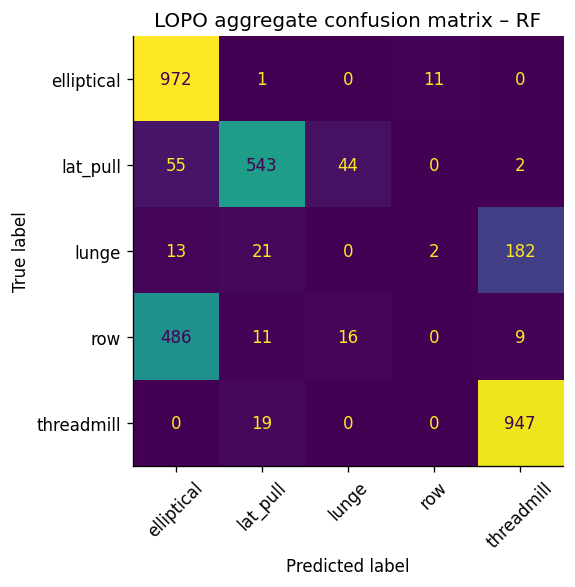

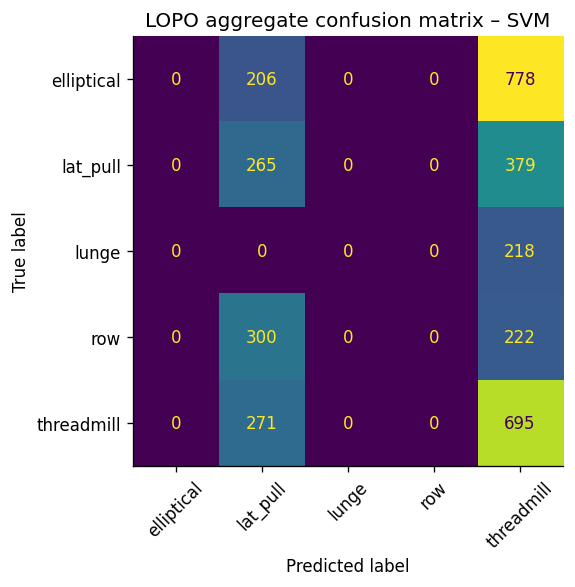

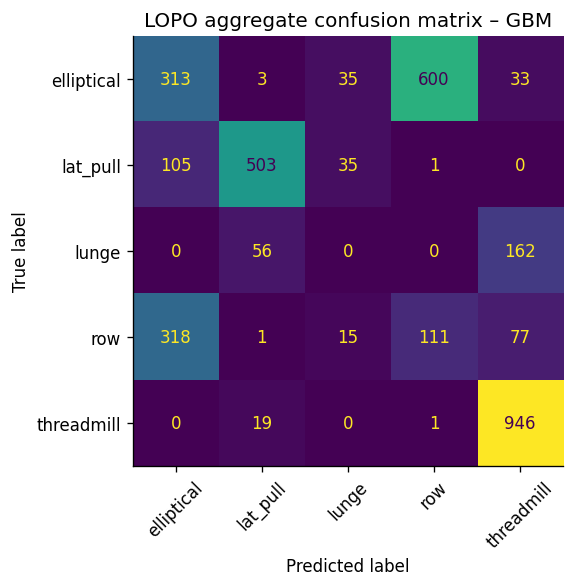

In [27]:
# ── 6b. DIRECTIONAL LOPO RESULTS ─────────────────────────────────────────────
# With only two participants the mean hides substantial asymmetry.
# Show per-direction metrics and one confusion matrix per direction.
# Note: participant and device are fully confounded — direction A→B also means
# device-A trained, device-B tested. The two effects cannot be separated.

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

lopo_abl = results.get("lopo", {}).get("ablation_classical", {})
lopo_classical = results.get("lopo", {}).get("classical", {})

# Extract per-fold data (stored by run_classical under "per_fold" key)
dir_rows = []
for mt, res in lopo_classical.items():
    for fold in res.get("per_fold", []):
        dir_rows.append({
            "Train→Test": f"all→{fold['fold']}",
            "Model": mt.upper(),
            "Macro-F1":  round(fold["macro_f1"],     4),
            "Bal. Acc":  round(fold["balanced_acc"],  4),
            "Accuracy":  round(fold["accuracy"],      4),
        })

if dir_rows:
    df_dir = pd.DataFrame(dir_rows).set_index(["Train→Test", "Model"])
    print("=== Directional LOPO – Classical models ===")
    print("Note: participant and device are fully confounded in this dataset.")
    display(df_dir)
else:
    print("Per-fold data not available in loaded results.")
    print("(Per-fold data is present only when results come from a live run, not a partial-save load.)")

# Confusion matrices from y_true / y_pred stored by run_classical
for mt, res in lopo_classical.items():
    if "y_true" not in res or not res["y_true"]:
        continue
    # y_true/y_pred are concatenated in LOPO order (fold 0 then fold 1)
    # We can only show an aggregate confusion matrix here
    labels_order = sorted(set(res["y_true"]))
    cm = confusion_matrix(res["y_true"], res["y_pred"], labels=labels_order)
    fig, ax = plt.subplots(figsize=(6, 5))
    disp = ConfusionMatrixDisplay(cm, display_labels=labels_order)
    disp.plot(ax=ax, colorbar=False, xticks_rotation=45)
    ax.set_title(f"LOPO aggregate confusion matrix – {mt.upper()}")
    plt.tight_layout()
    plt.savefig(f"./Plots/lopo_confusion_{mt}.png", dpi=150, bbox_inches="tight")
    plt.show()

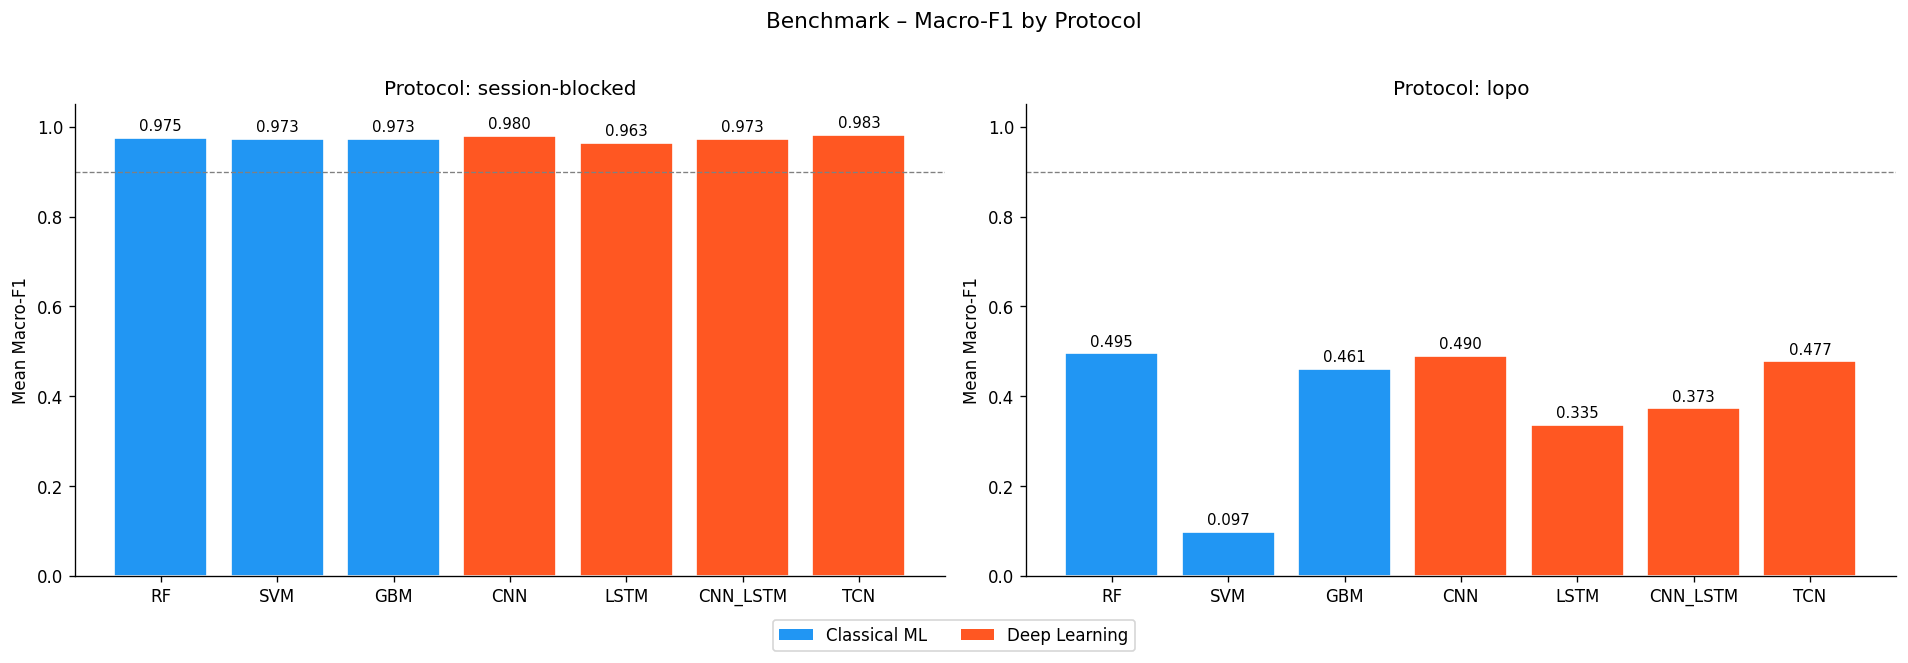

In [28]:
# ── 7. BENCHMARK BAR CHART ───────────────────────────────────────────────────
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=False)

for ax, strategy in zip(axes, ("session_blocked", "lopo")):
    sub = df_bench.xs(strategy, level="Protocol").reset_index()
    palette = ["#2196F3" if t == "Classical" else "#FF5722" for t in sub["Type"]]
    bars = ax.bar(sub["Model"], sub["Macro-F1"], color=palette, edgecolor="white")
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("Mean Macro-F1")
    ax.set_title(f"Protocol: {strategy.replace('_', '-')}")
    ax.axhline(0.9, color="gray", linestyle="--", linewidth=0.8)
    for bar, val in zip(bars, sub["Macro-F1"]):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                f"{val:.3f}", ha="center", va="bottom", fontsize=9)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#2196F3", label="Classical ML"),
    Patch(facecolor="#FF5722", label="Deep Learning"),
]
fig.legend(handles=legend_elements, loc="lower center", ncol=2, bbox_to_anchor=(0.5, -0.06))
plt.suptitle("Benchmark – Macro-F1 by Protocol", y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig("./Plots/benchmark_macro_f1.png", dpi=150, bbox_inches="tight")
plt.show()

In [29]:
# ── 8. SESSION-BLOCKED vs LOPO GENERALISATION GAP ────────────────────────────
# A large drop from session-blocked to LOPO indicates substantial
# cross-participant/device distribution shift. Because participant and device
# are confounded in this dataset, the source of the shift cannot be identified
# separately from the evaluation data alone.

gap_rows = []
for model in df_bench.index.get_level_values("Model").unique():
    try:
        sb  = df_bench.loc[("session_blocked", model), "Macro-F1"]
        lp  = df_bench.loc[("lopo",            model), "Macro-F1"]
        gap_rows.append({"Model": model, "Session-blocked": sb,
                         "LOPO": lp, "Gap (SB - LOPO)": round(sb - lp, 4)})
    except KeyError:
        pass

df_gap = pd.DataFrame(gap_rows).set_index("Model").sort_values("Gap (SB - LOPO)", ascending=False)
print("\n=== Generalisation Gap (Macro-F1) ===")
print(
    "A positive gap indicates reduced performance under cross-participant/device transfer.\n"
    "This is consistent with participant/device-specific features, but may also reflect\n"
    "class imbalance, calibration differences, sensor placement, or the limited number\n"
    "of training participants (n=2 means each LOPO fold trains on a single person)."
)
df_gap


=== Generalisation Gap (Macro-F1) ===
A positive gap indicates reduced performance under cross-participant/device transfer.
This is consistent with participant/device-specific features, but may also reflect
class imbalance, calibration differences, sensor placement, or the limited number
of training participants (n=2 means each LOPO fold trains on a single person).


,Session-blocked,LOPO,Gap (SB - LOPO)
Model,,,
SVM,0.9728,0.0972,0.8756
LSTM,0.9633,0.3353,0.6280
CNN_LSTM,0.9732,0.3727,0.6005
GBM,0.9733,0.4605,0.5128
TCN,0.9826,0.4774,0.5052
CNN,0.9799,0.4900,0.4899
RF,0.9753,0.4952,0.4801


In [30]:
# ── 9. ABLATION RESULTS TABLE ─────────────────────────────────────────────────
# Show the delta in Macro-F1 vs full-feature baseline for the RF model
# under both evaluation protocols.

def ablation_delta_table(results, strategy, metric="mean_macro_f1", model="rf"):
    abl = results[strategy].get("ablation_classical", {})
    if not abl:
        print(f"No ablation results for {strategy}.")
        return pd.DataFrame()
    baseline = abl.get("full", {}).get(model, {}).get(metric, float("nan"))
    rows = []
    for cond, res in abl.items():
        val = res.get(model, {}).get(metric, float("nan"))
        rows.append({
            "Condition": cond,
            metric:     round(val, 4),
            "delta":    round(val - baseline, 4) if cond != "full" else 0.0,
        })
    df = pd.DataFrame(rows).set_index("Condition")
    return df.sort_values("delta")

for strategy in ("session_blocked", "lopo"):
    print(f"\n=== Ablation – RF – {strategy} (Macro-F1 delta) ===")
    display(ablation_delta_table(results, strategy, metric="mean_macro_f1", model="rf"))


=== Ablation – RF – session_blocked (Macro-F1 delta) ===


,mean_macro_f1,delta
Condition,,
isolate_sensor_gyro,0.9464,-0.0289
isolate_gravity_aligned,0.9542,-0.0211
isolate_magnitude,0.9566,-0.0187
isolate_axis_y,0.9590,-0.0163
isolate_sensor_acc,0.9612,-0.0141
isolate_axis_x,0.9641,-0.0112
isolate_axis_z,0.9646,-0.0107
isolate_freq_domain,0.9655,-0.0098
isolate_correlations,0.9688,-0.0065



=== Ablation – RF – lopo (Macro-F1 delta) ===


,mean_macro_f1,delta
Condition,,
isolate_axis_y,0.0918,-0.4034
isolate_sensor_acc,0.1985,-0.2967
isolate_magnitude,0.2028,-0.2924
isolate_sensor_gyro,0.2330,-0.2622
isolate_gravity_aligned,0.2427,-0.2525
isolate_correlations,0.2641,-0.2311
isolate_freq_domain,0.2644,-0.2308
drop_axis_x,0.3296,-0.1656
isolate_axis_z,0.3305,-0.1647


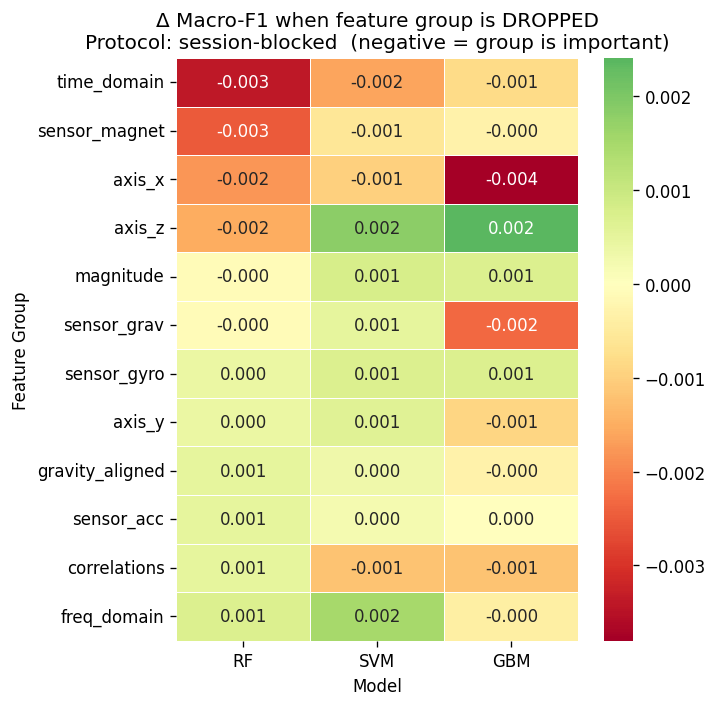

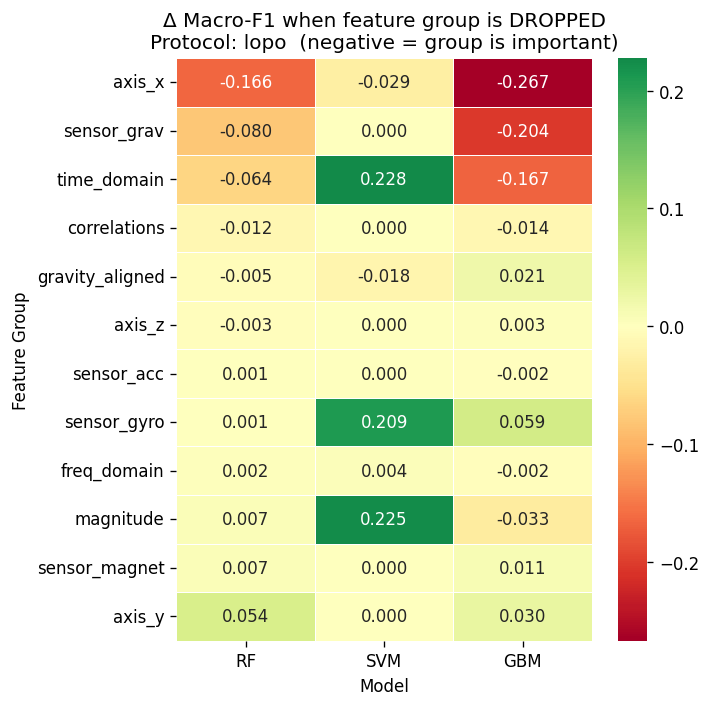

In [31]:
# ── 10. ABLATION HEAT-MAP (all classical models × all groups) ─────────────────
# Rows = feature groups (drop conditions only), columns = models.
# Cell value = Macro-F1 delta vs full baseline.
# Red = dropping that group hurts performance (group is important).

def ablation_heatmap(results, strategy, metric="mean_macro_f1", models=("rf", "svm", "gbm")):
    abl = results[strategy].get("ablation_classical", {})
    if not abl:
        print(f"No ablation data for {strategy}.")
        return
    baseline = {m: abl.get("full", {}).get(m, {}).get(metric, float("nan")) for m in models}
    drop_conds = [c for c in abl if c.startswith("drop_")]
    data = {}
    for cond in drop_conds:
        group = cond.replace("drop_", "")
        data[group] = {
            m.upper(): round(abl[cond].get(m, {}).get(metric, float("nan")) - baseline[m], 4)
            for m in models
        }
    df = pd.DataFrame(data).T.sort_values(list(data[list(data.keys())[0]].keys())[0])

    fig, ax = plt.subplots(figsize=(max(6, len(models) * 2), max(4, len(df) * 0.5)))
    sns.heatmap(
        df.astype(float), annot=True, fmt=".3f", cmap="RdYlGn",
        center=0, linewidths=0.5, ax=ax,
    )
    ax.set_title(f"Δ Macro-F1 when feature group is DROPPED\n"
                 f"Protocol: {strategy.replace('_', '-')}  "
                 f"(negative = group is important)")
    ax.set_xlabel("Model")
    ax.set_ylabel("Feature Group")
    plt.tight_layout()
    plt.savefig(f"./Plots/ablation_heatmap_{strategy}.png", dpi=150, bbox_inches="tight")
    plt.show()
    return df

for strategy in ("session_blocked", "lopo"):
    ablation_heatmap(results, strategy)


=== Ablation generalisation check – RF ===
Positive importance: removing the group reduced performance.
Positive 'LOPO - SB importance': the group matters more for cross-participant/device transfer.
Negative 'LOPO - SB importance': the group matters more under session-blocked evaluation.


Protocol,lopo,session_blocked,LOPO - SB importance
Group,,,
axis_x,0.1656,0.0018,0.1638
sensor_grav,0.0798,0.0001,0.0797
time_domain,0.0639,0.0034,0.0605
correlations,0.0118,-0.0005,0.0123
gravity_aligned,0.0051,-0.0005,0.0056
axis_z,0.0031,0.0015,0.0016
sensor_acc,-0.0005,-0.0005,0.0000
sensor_gyro,-0.0014,-0.0004,-0.0010
freq_domain,-0.0018,-0.0007,-0.0011


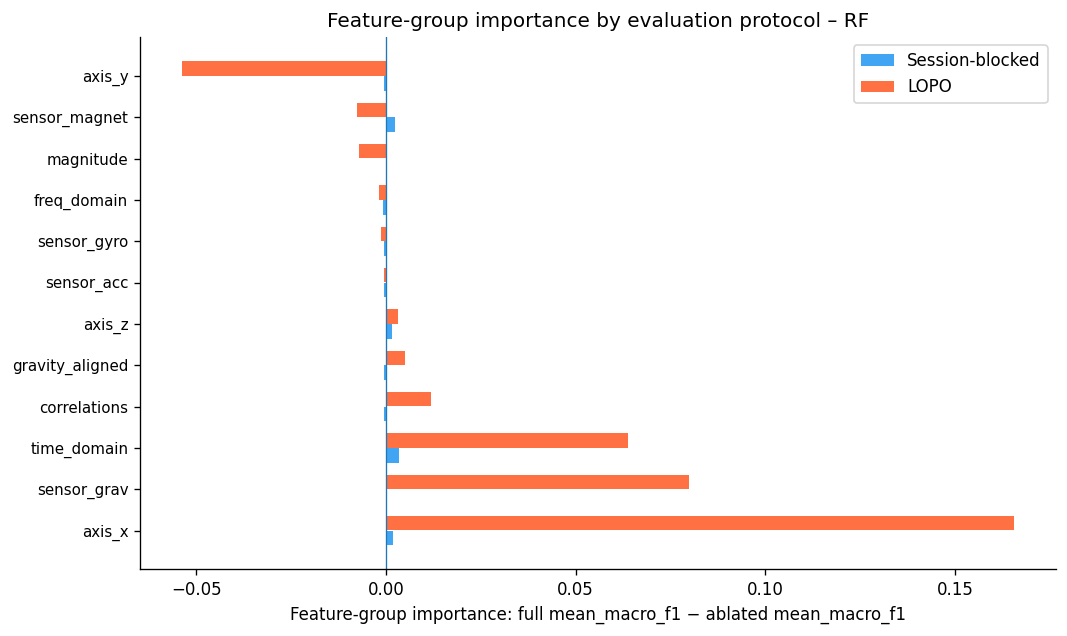

Protocol,lopo,session_blocked,LOPO - SB importance
Group,,,
axis_x,0.1656,0.0018,0.1638
sensor_grav,0.0798,0.0001,0.0797
time_domain,0.0639,0.0034,0.0605
correlations,0.0118,-0.0005,0.0123
gravity_aligned,0.0051,-0.0005,0.0056
axis_z,0.0031,0.0015,0.0016
sensor_acc,-0.0005,-0.0005,0.0000
sensor_gyro,-0.0014,-0.0004,-0.0010
freq_domain,-0.0018,-0.0007,-0.0011


In [32]:
# ── 11. GENERALISATION CHECK FOR ABLATION GROUPS ─────────────────────────────
# importance = full_score - ablated_score  (positive → group helped performance)
# "LOPO - SB importance" > 0: group matters more for cross-participant/device transfer
# "LOPO - SB importance" < 0: group matters more within-session

def ablation_generalisation(results, model="rf", metric="mean_macro_f1"):
    rows = []
    for strategy in ("session_blocked", "lopo"):
        abl = results[strategy].get("ablation_classical", {})
        if not abl:
            continue
        baseline = abl["full"][model][metric]
        for cond, res in abl.items():
            if not cond.startswith("drop_"):
                continue
            group       = cond.replace("drop_", "")
            ablated     = res[model][metric]
            importance  = round(baseline - ablated, 4)   # positive = group helped
            rows.append({"Group": group, "Protocol": strategy, "importance": importance})

    if not rows:
        return pd.DataFrame()

    df = (
        pd.DataFrame(rows)
        .pivot(index="Group", columns="Protocol", values="importance")
    )
    df["LOPO - SB importance"] = df["lopo"] - df["session_blocked"]
    df = df.sort_values("LOPO - SB importance", ascending=False)

    print(f"\n=== Ablation generalisation check – {model.upper()} ===")
    print("Positive importance: removing the group reduced performance.")
    print("Positive 'LOPO - SB importance': the group matters more for "
          "cross-participant/device transfer.")
    print("Negative 'LOPO - SB importance': the group matters more under "
          "session-blocked evaluation.")
    display(df)

    fig, ax = plt.subplots(figsize=(9, max(4, len(df) * 0.45)))
    x = np.arange(len(df))
    ax.barh(x - 0.18, df["session_blocked"], 0.35, label="Session-blocked", color="#2196F3", alpha=0.85)
    ax.barh(x + 0.18, df["lopo"],            0.35, label="LOPO",            color="#FF5722", alpha=0.85)
    ax.set_yticks(x)
    ax.set_yticklabels(df.index, fontsize=9)
    ax.axvline(0, linewidth=0.8)
    ax.set_xlabel(f"Feature-group importance: full {metric} − ablated {metric}")
    ax.set_title(f"Feature-group importance by evaluation protocol – {model.upper()}")
    ax.legend()
    plt.tight_layout()
    plt.savefig(f"./Plots/ablation_generalisation_{model}.png", dpi=150, bbox_inches="tight")
    plt.show()
    return df

ablation_generalisation(results, model="rf")